In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

In [10]:
seed_af_dir = "../../part1_refoldunfold/2_structure_prediction/parsed_results"
pseudo_af_dir = "../../part2_gpc_training/2_structure_prediction/parsed_results"
swissprot_dir = "../../part2_gpc_training/2_structure_prediction/parsed_results"

CONFIG = {
    "feats": ["length", "pTM", "pLDDT mean"],
    "target_col": "source",
    "pos_label": "AntiFam",
    "n_cv_splits": 5,
    "random_state": 42,
}

MODELS = {
    "colabfold": {
        "name": "AlphaFold2",
        "color": "darkslateblue",
        "file": "colabfold_info.csv",
    },
    "af3": {"name": "AlphaFold3", "color": "coral", "file": "af3_info.csv"},
    "esmfold": {"name": "ESMFold", "color": "darkgreen", "file": "esmfold_info.csv"},
}

DATA_SOURCES = {
    "af_train": {
        "dir": seed_af_dir,
        "prefix": "",
        "source": "AntiFam",
        "af_source": "Seed",
    },
    "af_test": {
        "dir": pseudo_af_dir,
        "prefix": "pseudo_antifams_",
        "source": "AntiFam",
        "af_source": "Generated",
    },
    "sp_train": {"dir": swissprot_dir, "prefix": "train_", "source": "Swiss-Prot"},
    "sp_test50": {"dir": swissprot_dir, "prefix": "test50_", "source": "Swiss-Prot"},
    "sp_test2": {"dir": swissprot_dir, "prefix": "test2_", "source": "Swiss-Prot"},
}

TEST_SAMPLES = {"af_test2": 100, "af_test50": 300, "sp_test98": 4900}


def load_csv(filepath, source, af_source=None):
    df = pd.read_csv(filepath)
    if "Unnamed: 0" in df.columns:
        df = df.rename(columns={"Unnamed: 0": "id"})
    df["source"] = source
    if af_source:
        df["AntiFam source"] = af_source
        if af_source == "Seed":
            # sort by ANF number then sequence number, keep first per ANF
            df = df.copy()
            df["anf_num"] = df["id"].str.extract(r"ANF0*(\d+)")[0].astype(int)
            df["seq_num"] = df["id"].str.extract(r"seq_(\d+)")[0].astype(int)
            df = df.sort_values(["anf_num", "seq_num"]).reset_index(drop=True)
            df["anf_prefix"] = df["id"].str.extract(r"(ANF\d+)")
            df = df[df.groupby("anf_prefix")["id"].transform("first") == df["id"]]
            df = df[df["id"] != "ANF00264_seq_1"]
            df = df.drop(columns=["anf_num", "seq_num", "anf_prefix"]).reset_index(
                drop=True
            )
    return df


def prepare_all_models():
    sampled_ids = None
    rs = CONFIG["random_state"]
    cols = ["id"] + CONFIG["feats"] + ["source"]

    # Load all data
    for model_info in MODELS.values():
        model_info["data"] = {
            split: load_csv(
                f"{src['dir']}/{src['prefix']}{model_info['file']}",
                src["source"],
                src.get("af_source"),
            )
            for split, src in DATA_SOURCES.items()
        }

    # Create train/test sets
    for model_info in MODELS.values():
        data = model_info["data"]

        if sampled_ids is None:
            sampled_ids = {
                "af_test2": set(
                    data["af_test"].sample(n=TEST_SAMPLES["af_test2"], random_state=rs)[
                        "id"
                    ]
                ),
                "af_test50": set(
                    data["af_test"].sample(
                        n=TEST_SAMPLES["af_test50"], random_state=rs
                    )["id"]
                ),
                "sp_test98": set(
                    data["sp_test2"].sample(
                        n=TEST_SAMPLES["sp_test98"], random_state=rs
                    )["id"]
                ),
            }

        model_info["training"] = pd.concat([data["af_train"], data["sp_train"]])[cols]
        model_info["testing"] = {
            "Test_2%": pd.concat(
                [
                    data["af_test"][
                        data["af_test"]["id"].isin(sampled_ids["af_test2"])
                    ],
                    data["sp_test2"][
                        data["sp_test2"]["id"].isin(sampled_ids["sp_test98"])
                    ],
                ]
            )[cols],
            "Test_50%": pd.concat(
                [
                    data["af_test"][
                        data["af_test"]["id"].isin(sampled_ids["af_test50"])
                    ],
                    data["sp_test50"],
                ]
            )[cols],
        }

In [11]:
def train_gpc_model(X_train, y_train, random_state=42):
    my_scaler = StandardScaler()
    X_train_scaled = my_scaler.fit_transform(X_train)
    kernel = RBF(length_scale=1.0)
    gpc = GaussianProcessClassifier(
        kernel=kernel, random_state=random_state, max_iter_predict=1000
    )
    gpc.fit(X_train_scaled, y_train)
    return gpc, my_scaler


def get_predictions(model, scaler, X, pos_label="AntiFam"):
    X_scaled = scaler.transform(X)
    positive_idx = list(model.classes_).index(pos_label)
    return model.predict_proba(X_scaled)[:, positive_idx]


def find_optimal_threshold_at_fpr_zero(fpr, tpr, thresholds):
    # Find indices where FPR is 0 (or essentially 0)
    zero_fpr_mask = fpr == 0

    if not np.any(zero_fpr_mask):
        # If no exact zero FPR, find the smallest FPR
        min_fpr_idx = np.argmin(fpr)
        return thresholds[min_fpr_idx], tpr[min_fpr_idx], fpr[min_fpr_idx]

    # Among FPR=0 points, find the one with highest TPR
    tpr_at_zero_fpr = tpr[zero_fpr_mask]
    thresholds_at_zero_fpr = thresholds[zero_fpr_mask]

    best_idx = np.argmax(tpr_at_zero_fpr)
    optimal_threshold = thresholds_at_zero_fpr[best_idx]
    optimal_tpr = tpr_at_zero_fpr[best_idx]

    return optimal_threshold, optimal_tpr, 0.0


def find_recall_at_100_precision(precision, recall, thresholds):
    # Precision of 1.0 (100%)
    perfect_precision_mask = precision == 1.0

    if not np.any(perfect_precision_mask):
        # Find highest precision available
        max_prec_idx = np.argmax(precision)
        return recall[max_prec_idx], precision[max_prec_idx]

    # Among 100% precision points, find highest recall
    recall_at_perfect = recall[perfect_precision_mask]
    max_recall = np.max(recall_at_perfect)

    return max_recall, 1.0


def plot_precision_recall_curves(pr_curves, model_name, model_color):
    fig, ax = plt.subplots(figsize=(4, 4))

    max_recall_at_precision_1_test2 = []
    max_recall_at_precision_1_test50 = []

    test2_data = pr_curves.get("Test_2%", [])
    if isinstance(test2_data, dict):
        test2_data = [test2_data]

    for curve_data in test2_data:
        ax.plot(
            curve_data["recall"],
            curve_data["precision"],
            color=model_color,
            alpha=0.5,
            linewidth=1.5,
        )
        # find highest recall where precision = 1.0
        precision = curve_data["precision"]
        recall = curve_data["recall"]
        max_recall = max(
            [r for p, r in zip(precision, recall) if p >= 1.0], default=None
        )
        if max_recall is not None:
            max_recall_at_precision_1_test2.append(max_recall)

    test50_data = pr_curves.get("Test_50%", [])
    if isinstance(test50_data, dict):
        test50_data = [test50_data]

    for curve_data in test50_data:
        ax.plot(
            curve_data["recall"],
            curve_data["precision"],
            color=model_color,
            linewidth=1.5,
        )
        precision = curve_data["precision"]
        recall = curve_data["recall"]
        max_recall = max(
            [r for p, r in zip(precision, recall) if p >= 1.0], default=None
        )
        if max_recall is not None:
            max_recall_at_precision_1_test50.append(max_recall)

    avg_max_recall_test2 = None
    avg_max_recall_test50 = None

    if max_recall_at_precision_1_test2:
        avg_max_recall_test2 = np.mean(max_recall_at_precision_1_test2)
        ax.axvline(
            x=avg_max_recall_test2,
            color=model_color,
            linestyle=":",
            alpha=0.5,
            linewidth=1.5,
        )

    if max_recall_at_precision_1_test50:
        avg_max_recall_test50 = np.mean(max_recall_at_precision_1_test50)
        ax.axvline(
            x=avg_max_recall_test50,
            color=model_color,
            linestyle="--",
            linewidth=1.5,
        )

    legend_elements = [
        Line2D([0], [0], color=model_color, alpha=0.5, linewidth=2, label="Test 2%"),
        Line2D([0], [0], color=model_color, linewidth=2, label="Test 50%"),
    ]
    ax.legend(handles=legend_elements, loc="lower left")

    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title(f"{model_name} GPC", fontsize=14)

    plt.tight_layout()
    fig.savefig(
        f"{model_name.replace(' ', '_')}_pr_curves.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

    return {
        "avg_recall_at_100_prec_test2": avg_max_recall_test2,
        "avg_recall_at_100_prec_test50": avg_max_recall_test50,
    }


def plot_roc_curves(roc_curves, model_name, model_color, test="Test_50%"):
    fig, ax = plt.subplots(figsize=(5, 5))

    if test in roc_curves:
        data = roc_curves[test]
        fpr, tpr, thresholds = data["fpr"], data["tpr"], data["thresholds"]
        roc_auc = data["auc"]

        ax.plot(
            fpr,
            tpr,
            color=model_color,
            lw=2,
            label=f"{model_name} (AUC = {roc_auc:.3f})",
        )

        opt_thresh, opt_tpr, opt_fpr = find_optimal_threshold_at_fpr_zero(
            fpr, tpr, thresholds
        )
        ax.scatter(
            [opt_fpr],
            [opt_tpr],
            color=model_color,
            s=40,
            linewidths=2,
            marker="o",
        )

        ax.annotate(
            f"Thresh={opt_thresh:.3f}\nTPR={opt_tpr:.3f}",
            xy=(opt_fpr, opt_tpr),
            xytext=(opt_fpr + 0.05, opt_tpr),
            fontsize=9,
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve - {model_name} ({test})")
    ax.legend(loc="lower right")

    plt.tight_layout()
    fig.savefig(
        f"{model_name.replace(' ', '_')}_roc_{test}.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

    return fig


def test_across_sets(train_df, test_sets, config):
    feature_cols = config["feats"]
    target_col = "source"
    pos_label = config.get("pos_label", "AntiFam")

    X_train = train_df[feature_cols].values
    y_train = train_df[target_col].values

    model, scaler = train_gpc_model(X_train, y_train, config.get("random_state", 42))

    results = []
    roc_curves = {}
    pr_curves = {}

    for test_name, test_df in test_sets.items():
        X_test = test_df[feature_cols].values
        y_test = test_df[target_col].values

        y_proba = get_predictions(model, scaler, X_test, pos_label)
        y_true_binary = (y_test == pos_label).astype(int)

        fpr, tpr, roc_thresholds = roc_curve(y_true_binary, y_proba)
        roc_auc = auc(fpr, tpr)

        opt_thresh, tpr_at_fpr0, _ = find_optimal_threshold_at_fpr_zero(
            fpr, tpr, roc_thresholds
        )

        precision, recall, pr_thresholds = precision_recall_curve(
            y_true_binary, y_proba
        )
        avg_precision = average_precision_score(y_true_binary, y_proba)

        recall_at_100_prec, _ = find_recall_at_100_precision(
            precision, recall, pr_thresholds
        )

        roc_curves[test_name] = {
            "fpr": fpr,
            "tpr": tpr,
            "thresholds": roc_thresholds,
            "auc": roc_auc,
        }

        pr_curves[test_name] = {
            "precision": precision,
            "recall": recall,
            "thresholds": pr_thresholds,
            "average_precision": avg_precision,
        }

        results.append(
            {
                "test_set": test_name,
                "auc": roc_auc,
                "average_precision": avg_precision,
                "tpr_at_fpr_zero": tpr_at_fpr0,
                "optimal_threshold": opt_thresh,
                "recall_at_100_precision": recall_at_100_prec,
            }
        )

    results_df = pd.DataFrame(results)
    return results_df, roc_curves, pr_curves, model, scaler


def cross_validate_model(train_df, config, n_splits=5):
    feature_cols = config["feats"]
    target_col = "source"
    pos_label = config.get("pos_label", "AntiFam")
    random_state = config.get("random_state", 42)

    X = train_df[feature_cols].values
    y = train_df[target_col].values
    y_binary = (y == pos_label).astype(int)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cv_aucs = []
    cv_recalls_at_100_prec = []

    for train_idx, val_idx in cv.split(X, y_binary):
        X_train_cv, X_val_cv = X[train_idx], X[val_idx]
        y_train_cv, y_val_cv = y[train_idx], y[val_idx]
        y_val_binary = y_binary[val_idx]

        model, scaler = train_gpc_model(X_train_cv, y_train_cv, random_state)

        y_proba = get_predictions(model, scaler, X_val_cv, pos_label)

        # ROC AUC
        fpr, tpr, _ = roc_curve(y_val_binary, y_proba)
        fold_auc = auc(fpr, tpr)
        cv_aucs.append(fold_auc)

        precision, recall, pr_thresholds = precision_recall_curve(y_val_binary, y_proba)
        recall_at_100, _ = find_recall_at_100_precision(
            precision, recall, pr_thresholds
        )
        cv_recalls_at_100_prec.append(recall_at_100)

    cv_results = {
        "cv_auc_mean": np.mean(cv_aucs),
        "cv_auc_std": np.std(cv_aucs),
        "cv_recall_at_100_prec_mean": np.mean(cv_recalls_at_100_prec),
        "cv_recall_at_100_prec_std": np.std(cv_recalls_at_100_prec),
        "cv_aucs": cv_aucs,
        "cv_recalls_at_100_prec": cv_recalls_at_100_prec,
    }

    return cv_results


def plot_combined_roc_curves(all_model_data, test_type="Test_50%"):
    fig, ax = plt.subplots(figsize=(4, 4))

    for model_data in all_model_data:
        name = model_data["name"]
        color = model_data["color"]
        roc_curves = model_data["roc_curves"]

        if test_type not in roc_curves:
            print(f"Warning: {test_type} not found for {name}")
            continue

        data = roc_curves[test_type]
        fpr, tpr, thresholds = data["fpr"], data["tpr"], data["thresholds"]
        roc_auc = data["auc"]

        ax.plot(
            fpr,
            tpr,
            color=color,
            lw=1.5,
            alpha=0.8,
            label=f"{name} (AUC = {roc_auc:.3f})",
        )

        # find and mark optimal threshold at FPR=0
        opt_thresh, opt_tpr, opt_fpr = find_optimal_threshold_at_fpr_zero(
            fpr, tpr, thresholds
        )

        ax.scatter(
            [opt_fpr],
            [opt_tpr],
            color=color,
            s=30,
            alpha=0.8,
            linewidths=1.5,
            marker="o",
        )

        ax.annotate(
            f"{opt_thresh:.3f}",
            xy=(opt_fpr, opt_tpr),
            xytext=(opt_fpr + 0.02, opt_tpr),
            fontsize=8,
        )

    # Plot random classifier line
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)

    ax.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    fig.savefig(f"combined_roc_{test_type}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return fig

Test_2%: 5000 samples ✓
Test_50%: 600 samples ✓

Running pipeline for: AlphaFold2

Performing cross-validation...
  CV AUC: 0.986 ± 0.008
  CV Recall@100%Prec: 0.787 ± 0.087

Testing across test sets...

Test Set Results:
test_set      auc  average_precision  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision
 Test_2% 0.963420           0.865924         0.460000           0.945309                 0.460000
Test_50% 0.970189           0.977729         0.396667           0.947204                 0.396667


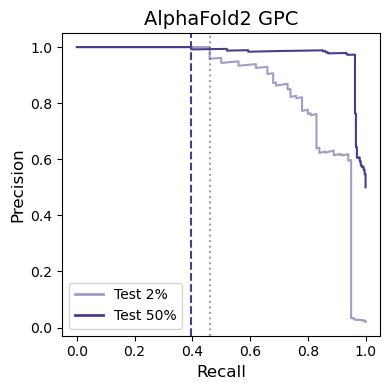


Running pipeline for: AlphaFold3

Performing cross-validation...
  CV AUC: 0.981 ± 0.015
  CV Recall@100%Prec: 0.710 ± 0.188

Testing across test sets...

Test Set Results:
test_set      auc  average_precision  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision
 Test_2% 0.981412           0.892824         0.370000           0.954073                 0.370000
Test_50% 0.982922           0.988366         0.586667           0.900268                 0.586667


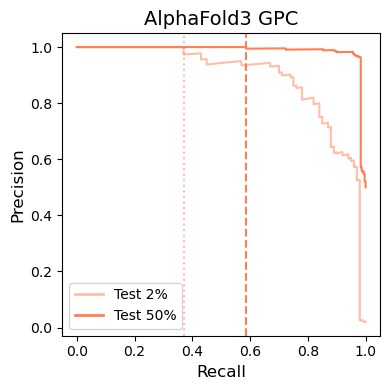


Running pipeline for: ESMFold

Performing cross-validation...
  CV AUC: 0.980 ± 0.008
  CV Recall@100%Prec: 0.707 ± 0.120

Testing across test sets...

Test Set Results:
test_set      auc  average_precision  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision
 Test_2% 0.967459           0.778045         0.040000           0.975092                 0.040000
Test_50% 0.974778           0.983491         0.493333           0.951015                 0.493333


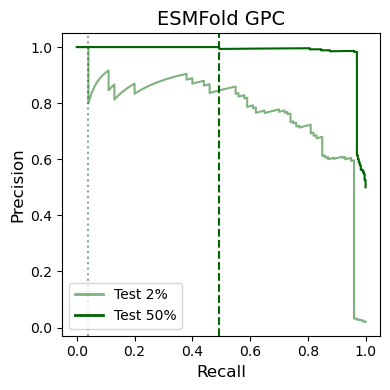


Combined Results Summary
test_set      auc  average_precision  tpr_at_fpr_zero  optimal_threshold  recall_at_100_precision  cv_auc_mean  cv_auc_std  cv_recall_at_100_prec_mean  cv_recall_at_100_prec_std      model
 Test_2% 0.963420           0.865924         0.460000           0.945309                 0.460000     0.985950    0.008178                    0.787078                   0.087122 AlphaFold2
Test_50% 0.970189           0.977729         0.396667           0.947204                 0.396667     0.985950    0.008178                    0.787078                   0.087122 AlphaFold2
 Test_2% 0.981412           0.892824         0.370000           0.954073                 0.370000     0.980528    0.014635                    0.709545                   0.187717 AlphaFold3
Test_50% 0.982922           0.988366         0.586667           0.900268                 0.586667     0.980528    0.014635                    0.709545                   0.187717 AlphaFold3
 Test_2% 0.967459           0

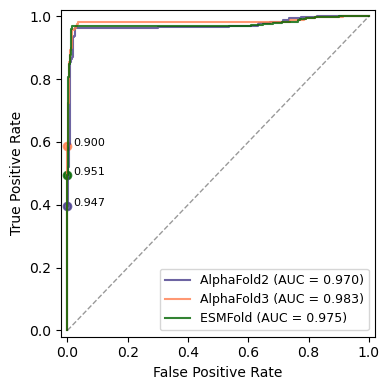

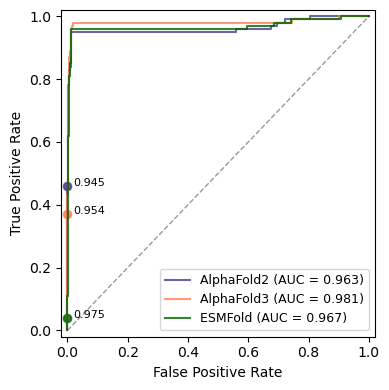

In [12]:
def run_model_pipeline(model, training, testing_sets, config):
    print(f"\n{'=' * 60}")
    print(f"Running pipeline for: {model['name']}")
    print(f"{'=' * 60}")

    print("\nPerforming cross-validation...")
    cv_results = cross_validate_model(training, config)
    print(f"  CV AUC: {cv_results['cv_auc_mean']:.3f} ± {cv_results['cv_auc_std']:.3f}")
    print(
        f"  CV Recall@100%Prec: {cv_results['cv_recall_at_100_prec_mean']:.3f} ± {cv_results['cv_recall_at_100_prec_std']:.3f}"
    )

    print("\nTesting across test sets...")
    test_results, roc_curves, pr_curves, trained_model, scaler = test_across_sets(
        training,
        testing_sets,
        config,
    )

    print("\nTest Set Results:")
    print(test_results.to_string(index=False))

    plot_precision_recall_curves(pr_curves, model["name"], model["color"])

    # combine all results
    all_results = test_results.copy()
    all_results["cv_auc_mean"] = cv_results["cv_auc_mean"]
    all_results["cv_auc_std"] = cv_results["cv_auc_std"]
    all_results["cv_recall_at_100_prec_mean"] = cv_results["cv_recall_at_100_prec_mean"]
    all_results["cv_recall_at_100_prec_std"] = cv_results["cv_recall_at_100_prec_std"]

    model["trained_model"] = trained_model
    model["scaler"] = scaler

    return all_results, roc_curves


def run_all_models():
    all_model_roc_data = []
    all_results = []

    for model_key in MODELS:
        model = MODELS[model_key]

        results, roc_curves = run_model_pipeline(
            model,
            model["training"],
            model["testing"],
            CONFIG,
        )

        all_model_roc_data.append(
            {
                "name": model["name"],
                "color": model["color"],
                "roc_curves": roc_curves,
                "results": results.to_dict("records"),
            }
        )

        results["model"] = model["name"]
        all_results.append(results)

    combined_results = pd.concat(all_results, ignore_index=True)
    print("\n" + "=" * 60)
    print("Combined Results Summary")
    print("=" * 60)
    print(combined_results.to_string(index=False))

    # plot combined ROC curves for each test set
    plot_combined_roc_curves(all_model_roc_data, "Test_50%")
    plot_combined_roc_curves(all_model_roc_data, "Test_2%")

    return combined_results, all_model_roc_data


prepare_all_models()
results_df, roc_data = run_all_models()